# Salama Health — Data Processing Pipeline v2
### Load → Clean → Merge → Feature Engineer → Save

| Source | Data | CDI Component |
|---|---|---|
| Sentinel-1 SAR | VV backscatter per facility | P(flood) |
| SRTM | Elevation per facility | P(flood), P(cutoff) |
| CHIRPS | Weekly rainfall by county | P(flood) |
| Open-Meteo ERA5 | Temperature, humidity, ET | P(CCF) |
| OCHA Flood Data | Flood-affected people by county | P(flood) label |
| IOM DTM | IDP counts by county | P(disp) |

## 0. Setup

In [1]:
!pip install tqdm -q

import pandas as pd
import numpy as np
import requests
import os
import time
import json
import warnings
from io import BytesIO, StringIO
from tqdm import tqdm

warnings.filterwarnings('ignore')

FLOOD_DIR    = '/kaggle/input/datasets/mubarakabanadda/floodscan-south-sudan-data'
DTM_DIR      = '/kaggle/input/datasets/mubarakabanadda/displacement-data'
CHIRPS_DIR   = '/kaggle/input/datasets/mubarakabanadda/ssd-rainfall-subnat'
SENTINEL_DIR = '/kaggle/input/datasets/mubarakabanadda/sentinel-1-sar'
SRTM_DIR     = '/kaggle/input/datasets/mubarakabanadda/srtm-elevation'
OUT_DIR      = '/kaggle/working'

os.makedirs(OUT_DIR, exist_ok=True)
print('Setup complete')

Setup complete


## 1. Load Sentinel-1 and SRTM

In [2]:
s1_df = pd.read_csv(f'{SENTINEL_DIR}/SSD_Sentinel1_VV_2019_2024 (1).csv')
s1_df['date']           = pd.to_datetime(s1_df['date'], errors='coerce')
s1_df['VV_backscatter'] = pd.to_numeric(s1_df['VV_backscatter'], errors='coerce')
s1_df['latitude']       = pd.to_numeric(s1_df['latitude'],  errors='coerce')
s1_df['longitude']      = pd.to_numeric(s1_df['longitude'], errors='coerce')
s1_df = s1_df.dropna(subset=['date','VV_backscatter'])

facilities = (
    s1_df[['facility_name','state','county','latitude','longitude']]
    .drop_duplicates('facility_name')
    .reset_index(drop=True)
)

srtm_df = pd.read_csv(f'{SRTM_DIR}/SSD_SRTM_Elevation (3).csv')
srtm_df['elevation_m'] = pd.to_numeric(srtm_df['elevation_m'], errors='coerce')
srtm_df = srtm_df[['facility_name','elevation_m']].dropna()

print(f'S1:         {len(s1_df):,} rows | {len(facilities)} facilities')
print(f'SRTM:       {len(srtm_df)} facilities')
print(f'States:     {list(s1_df["state"].unique())}')
print(f'Date range: {s1_df["date"].min().date()} to {s1_df["date"].max().date()}')

S1:         18,223 rows | 93 facilities
SRTM:       93 facilities
States:     ['Jonglei', 'Unity', 'Upper Nile']
Date range: 2019-01-01 to 2024-12-30


## 2. Load and Process CHIRPS Rainfall

In [3]:
chirps_raw = pd.read_csv(f'{CHIRPS_DIR}/ssd-rainfall-subnat-5ytd.csv')
chirps_raw['date']            = pd.to_datetime(chirps_raw['date'], errors='coerce')
chirps_raw['rainfall_mm']     = pd.to_numeric(chirps_raw['rfh'],     errors='coerce')
chirps_raw['rainfall_avg_mm'] = pd.to_numeric(chirps_raw['rfh_avg'], errors='coerce')

chirps_raw = chirps_raw[
    (chirps_raw['date'].dt.year >= 2019) &
    (chirps_raw['date'].dt.year <= 2024) &
    (chirps_raw['PCODE'].str.startswith(('SS03','SS06','SS07')))
].copy()

pcode_map = {
    'SS0601':'Guit',           'SS0602':'Koch',
    'SS0603':'Leer',           'SS0604':'Mayendit',
    'SS0605':'Mayom',          'SS0606':'Panyijiar',
    'SS0607':'Rubkona',        'SS0608':'Abiemnhom',
    'SS0609':'Budong Budong',
    'SS0301':'Ayod',           'SS0302':'Bor South',
    'SS0303':'Duk',            'SS0304':'Fangak',
    'SS0305':'Nyirol',         'SS0306':'Pibor',
    'SS0307':'Pochalla',       'SS0308':'Twic East',
    'SS0309':'Uror',           'SS0310':'Canal Pigi',
    'SS0311':'Maiwut',
    'SS0701':'Akoka',          'SS0702':'Baliet',
    'SS0703':'Fashoda',        'SS0704':'Longochuk',
    'SS0705':'Luakpiny Nasir', 'SS0706':'Maban',
    'SS0707':'Manyo',          'SS0708':'Melut',
    'SS0709':'Panyikang',      'SS0710':'Renk',
    'SS0711':'Ulang',          'SS0712':'Makal',
}

county_fixes = {
    'Bor':            'Bor South',
    'Canal':          'Canal Pigi',
    'Luakpiny/Nasir': 'Luakpiny Nasir',
    'Malakal':        'Makal',
    'Panyijar':       'Panyijiar',
    'Pariang':        'Mayom',
    'Akobo':          'Uror',
}

chirps_raw['county'] = chirps_raw['PCODE'].map(pcode_map)
chirps_raw = chirps_raw.dropna(subset=['county'])
chirps_raw['week'] = chirps_raw['date'].dt.to_period('W').dt.start_time

chirps_weekly = (
    chirps_raw
    .groupby(['county','week'])
    .agg(
        chirps_rainfall_mm  = ('rainfall_mm',     'sum'),
        chirps_rainfall_avg = ('rainfall_avg_mm', 'mean'),
    )
    .reset_index()
)
chirps_weekly['chirps_anomaly'] = chirps_weekly['chirps_rainfall_mm'] - chirps_weekly['chirps_rainfall_avg']

print(f'CHIRPS rows:    {len(chirps_weekly):,}')
print(f'Counties:       {chirps_weekly["county"].nunique()}')
print(f'Date range:     {chirps_weekly["week"].min().date()} to {chirps_weekly["week"].max().date()}')
print(f'Rainfall range: {chirps_weekly["chirps_rainfall_mm"].min():.1f} to {chirps_weekly["chirps_rainfall_mm"].max():.1f} mm')

CHIRPS rows:    3,456
Counties:       32
Date range:     2021-12-27 to 2024-12-16
Rainfall range: 0.0 to 103.8 mm


## 3. Load OCHA Flood Data

In [4]:
flood_files = [f'{FLOOD_DIR}/{f}' for f in os.listdir(FLOOD_DIR) if f.endswith('.xlsx')]
print(f'Flood files: {len(flood_files)}')

all_flood = []
for fpath in flood_files:
    try:
        xl  = pd.ExcelFile(fpath)
        tmp = xl.parse(xl.sheet_names[0])
        tmp['source_file'] = os.path.basename(fpath)
        all_flood.append(tmp)
    except Exception as e:
        print(f'  Failed: {os.path.basename(fpath)}: {e}')

flood_records = []
for df_tmp in all_flood:
    cols = [c.lower().strip() for c in df_tmp.columns]
    df_tmp.columns = cols
    county_col   = next((c for c in cols if 'county' in c), None)
    state_col    = next((c for c in cols if 'state' in c), None)
    affected_col = next((c for c in cols
                        if any(x in c for x in ['affected','flooded','people','total'])), None)
    if county_col and affected_col:
        rec = df_tmp[[county_col, affected_col]].copy()
        rec.columns = ['county','people_affected']
        if state_col:
            rec['state'] = df_tmp[state_col].values
        rec['people_affected'] = pd.to_numeric(rec['people_affected'], errors='coerce').fillna(0)
        rec['county']          = rec['county'].astype(str).str.strip().str.title()
        flood_records.append(rec)

if flood_records:
    flood_df = pd.concat(flood_records, ignore_index=True)
    if 'state' in flood_df.columns:
        flood_df = flood_df[
            flood_df['state'].astype(str).str.strip().str.title()
            .isin(['Unity','Jonglei','Upper Nile'])
        ]
    flood_county = (
        flood_df.groupby('county')['people_affected']
        .max().reset_index()
    )
    flood_county['flood_affected_normalised'] = (
        flood_county['people_affected'] / flood_county['people_affected'].max()
    )
    print(f'Flood counties: {len(flood_county)}')
    print(flood_county.sort_values('people_affected', ascending=False).head(5).to_string(index=False))
else:
    flood_county = None
    print('No flood data parsed')

Flood files: 5
Flood counties: 37
   county  people_affected  flood_affected_normalised
   Fangak          67191.0                   1.000000
    Mayom          60000.0                   0.892977
Twic East          58069.0                   0.864238
     Ayod          55000.0                   0.818562
  Rubkona          52247.0                   0.777589


## 4. Load IOM DTM Displacement

In [5]:
dtm_files = sorted([f'{DTM_DIR}/{f}' for f in os.listdir(DTM_DIR)
                    if f.endswith('.xlsx') or f.endswith('.xls')])

all_dtm = []
for fpath in dtm_files:
    try:
        xl   = pd.ExcelFile(fpath)
        name = os.path.basename(fpath)
        best_sheet, best_rows = xl.sheet_names[0], 0
        for s in xl.sheet_names:
            tmp = xl.parse(s)
            if len(tmp) > best_rows:
                best_rows  = len(tmp)
                best_sheet = s
        df_tmp = xl.parse(best_sheet)
        df_tmp['source_round'] = name
        all_dtm.append((name, df_tmp))
    except Exception as e:
        print(f'Failed {os.path.basename(fpath)}: {e}')

print(f'DTM files loaded: {len(all_dtm)}')

PILOT_PCODES = ['ss03','ss06','ss07']
PILOT_STATES = ['unity','jonglei','upper nile']
dtm_records  = []

for name, df_tmp in all_dtm:
    df_tmp    = df_tmp.reset_index(drop=True)
    orig_cols = list(df_tmp.columns)
    lower_map = {c: c.lower().strip() for c in orig_cols}
    df_tmp    = df_tmp.rename(columns=lower_map)
    col_list  = list(df_tmp.columns)

    county_col = next((c for c in col_list
                      if c in ['county name','county','county_name','admin 2']), None)
    state_col  = next((c for c in col_list
                      if c in ['state name','state','state_name','admin 1',
                                'state_pcode','county_pcode','county pcode',
                                'admin 1 pcode']), None)

    idp_col = None
    idp_col = idp_col or next((c for c in col_list
                               if 'total no# of idps ind#' in c), None)
    idp_col = idp_col or next((c for c in col_list if c == '# of ind'), None)
    idp_col = idp_col or next((c for c in col_list if c == 't idp ind'), None)
    idp_col = idp_col or next((c for c in col_list
                               if 'total number of idp individuals' in c), None)
    idp_col = idp_col or next((c for c in col_list
                               if 'estimated' in c and 'idp individual' in c
                               and 'total' in c), None)
    idp_col = idp_col or next((c for c in col_list
                               if c == 'a_idp_inds_ssd'), None)
    idp_col = idp_col or next((c for c in col_list
                               if c == 'a_idp_hhs_ssd'), None)

    if not county_col or not idp_col:
        continue

    rec = pd.DataFrame()
    rec['county']    = df_tmp[county_col].astype(str).str.strip().str.title()
    rec['idp_count'] = pd.to_numeric(df_tmp[idp_col], errors='coerce').fillna(0)
    rec['source_round'] = name

    if state_col:
        state_vals = df_tmp[state_col].astype(str).str.strip().str.lower()
        pilot_mask = (
            state_vals.isin(PILOT_PCODES) |
            state_vals.isin(PILOT_STATES) |
            state_vals.str.startswith(('ss03','ss06','ss07'))
        )
        rec = rec[pilot_mask.values]

    if len(rec) > 0:
        dtm_records.append(rec)

if dtm_records:
    dtm_df = pd.concat(dtm_records, ignore_index=True)
    dtm_df['county'] = dtm_df['county'].replace({
        'Canal/Pigi':     'Canal Pigi',
        'Luakpiny/Nasir': 'Luakpiny Nasir',
    })
    dtm_county = (
        dtm_df.groupby('county')['idp_count']
        .mean().reset_index()
        .rename(columns={'idp_count':'idp_avg'})
    )
    dtm_county = dtm_county[dtm_county['idp_avg'] > 0]
    dtm_county['idp_normalised'] = dtm_county['idp_avg'] / dtm_county['idp_avg'].max()
    print(f'DTM counties: {len(dtm_county)}')
    print(dtm_county.sort_values('idp_avg', ascending=False).head(5).to_string(index=False))
else:
    dtm_county = None
    print('No DTM data parsed')

DTM files loaded: 14
DTM counties: 32
    county     idp_avg  idp_normalised
     Melut 2582.951049        1.000000
   Rubkona 2068.885806        0.800978
 Bor South 2032.985075        0.787078
Canal Pigi 1880.441558        0.728021
       Duk 1735.705357        0.671985


## 5. Download Open-Meteo Climate Data
Temperature, humidity and evapotranspiration for P(CCF).

**Rate limit handling:** Open-Meteo free tier allows ~60 requests/minute.
This cell uses 2 second delay between calls and auto-retries failed facilities
with exponential backoff. Progress is saved after each batch so no work is lost.

In [6]:
climate_cache   = f'{OUT_DIR}/openmeteo_climate.csv'
progress_cache  = f'{OUT_DIR}/openmeteo_progress.json'

VARS = [
    'temperature_2m_max',
    'temperature_2m_min',
    'relative_humidity_2m_max',
    'et0_fao_evapotranspiration',
]

def fetch_one_facility(row, max_retries=3):
    """Fetch one facility with retry and exponential backoff."""
    for attempt in range(max_retries):
        try:
            r = requests.get(
                'https://archive-api.open-meteo.com/v1/archive',
                params={
                    'latitude':   round(float(row['latitude']),  4),
                    'longitude':  round(float(row['longitude']), 4),
                    'start_date': '2019-01-01',
                    'end_date':   '2024-12-31',
                    'daily':      ','.join(VARS),
                    'timezone':   'Africa/Nairobi',
                },
                timeout=60
            )
            data = r.json()

            if 'error' in data:
                reason = data.get('reason','')
                if 'limit exceeded' in reason.lower():
                    wait = 60 * (attempt + 1)  # 60s, 120s, 180s
                    print(f'  Rate limit hit — waiting {wait}s before retry {attempt+1}')
                    time.sleep(wait)
                    continue
                return None, reason

            daily  = data.get('daily', {})
            if not daily or 'time' not in daily:
                return None, 'no daily data'

            df_row = pd.DataFrame({'date': pd.to_datetime(daily['time'])})
            for var in VARS:
                df_row[var] = daily.get(var, np.nan)
            df_row['facility_name'] = row['facility_name']
            df_row['state']         = row['state']
            df_row['county']        = row['county']
            return df_row, None

        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(10)
            else:
                return None, str(e)

    return None, 'max retries exceeded'


# Load existing progress
if os.path.exists(climate_cache):
    climate_df = pd.read_csv(climate_cache)
    climate_df['date'] = pd.to_datetime(climate_df['date'])
    done = set(climate_df['facility_name'].unique())
    print(f'Resuming — already have {len(done)} facilities')
else:
    climate_df = pd.DataFrame()
    done = set()

# Find remaining facilities
remaining = facilities[~facilities['facility_name'].isin(done)].reset_index(drop=True)
print(f'Remaining to fetch: {len(remaining)}')

if len(remaining) > 0:
    new_dfs = []
    failed  = []

    for i, (_, row) in enumerate(remaining.iterrows()):
        df_row, err = fetch_one_facility(row)

        if df_row is not None:
            new_dfs.append(df_row)
        else:
            failed.append((row['facility_name'], err))

        # Save progress every 10 facilities
        if (i + 1) % 10 == 0 or i == len(remaining) - 1:
            if new_dfs:
                batch    = pd.concat(new_dfs, ignore_index=True)
                climate_df = pd.concat([climate_df, batch], ignore_index=True)
                climate_df.to_csv(climate_cache, index=False)
                new_dfs  = []
                done     = set(climate_df['facility_name'].unique())
            print(f'Progress: {i+1}/{len(remaining)} | Saved: {len(done)} | Failed: {len(failed)}')

        time.sleep(2)  # 2 second delay — stays under 30 req/min rate limit

    print(f'\nCompleted: {len(done)} facilities | Failed: {len(failed)}')
    if failed:
        print('Failed facilities:')
        for name, err in failed:
            print(f'  {name}: {err}')

print(f'\nClimate data: {len(climate_df):,} rows | {climate_df["facility_name"].nunique()} facilities')
print(f'Temp range: {climate_df["temperature_2m_max"].min():.1f} to {climate_df["temperature_2m_max"].max():.1f} C')

Remaining to fetch: 93
Progress: 10/93 | Saved: 10 | Failed: 0
Progress: 20/93 | Saved: 20 | Failed: 0
Progress: 30/93 | Saved: 30 | Failed: 0
Progress: 40/93 | Saved: 40 | Failed: 0
Progress: 50/93 | Saved: 50 | Failed: 0
Progress: 60/93 | Saved: 60 | Failed: 0
Progress: 70/93 | Saved: 70 | Failed: 0
Progress: 80/93 | Saved: 80 | Failed: 0
Progress: 90/93 | Saved: 90 | Failed: 0
  Rate limit hit — waiting 60s before retry 1
  Rate limit hit — waiting 120s before retry 2
  Rate limit hit — waiting 180s before retry 3
  Rate limit hit — waiting 60s before retry 1
  Rate limit hit — waiting 120s before retry 2
  Rate limit hit — waiting 180s before retry 3
Progress: 93/93 | Saved: 91 | Failed: 2

Completed: 91 facilities | Failed: 2
Failed facilities:
  Oang PHCC: max retries exceeded
  Churi PHCC: max retries exceeded

Climate data: 199,472 rows | 91 facilities
Temp range: 22.9 to 45.0 C


In [7]:
# Weekly aggregation of climate data
climate_df['date'] = pd.to_datetime(climate_df['date'], errors='coerce')
climate_df['week'] = climate_df['date'].dt.to_period('W').dt.start_time

climate_weekly = (
    climate_df
    .groupby(['facility_name','week'])
    .agg(
        temp_max_celsius   = ('temperature_2m_max',        'max'),
        temp_min_celsius   = ('temperature_2m_min',        'min'),
        humidity_pct       = ('relative_humidity_2m_max',  'mean'),
        evapotranspiration = ('et0_fao_evapotranspiration','sum'),
    )
    .reset_index()
)
CLIMATE_ACTIVE = True
print(f'Climate weekly: {len(climate_weekly):,} rows | {climate_weekly["facility_name"].nunique()} facilities')
print(f'Temp range: {climate_weekly["temp_max_celsius"].min():.1f} to {climate_weekly["temp_max_celsius"].max():.1f} C')

Climate weekly: 28,574 rows | 91 facilities
Temp range: 28.5 to 45.0 C


## 6. Merge All Datasets

In [8]:
# Spine: Sentinel-1
df = s1_df[['facility_name','state','county','latitude','longitude',
            'date','VV_backscatter']].copy()
df['date']          = pd.to_datetime(df['date'], errors='coerce')
df                  = df.dropna(subset=['date'])
df['week']          = df['date'].dt.to_period('W').dt.start_time
df['county_chirps'] = df['county'].str.strip().str.title().replace(county_fixes)
print(f'Spine: {len(df):,} rows')

# SRTM
df = df.merge(srtm_df, on='facility_name', how='left')
print(f'After SRTM: {len(df):,} rows')

# CHIRPS
chirps_weekly['county'] = chirps_weekly['county'].str.strip().str.title()
df = df.merge(
    chirps_weekly,
    left_on  = ['county_chirps','week'],
    right_on = ['county','week'],
    how='left'
).drop(columns=['county_y'], errors='ignore').rename(columns={'county_x':'county'})
print(f'After CHIRPS: {len(df):,} | rainfall nulls: {df["chirps_rainfall_mm"].isna().sum()}')

# Open-Meteo
if CLIMATE_ACTIVE:
    df = df.merge(climate_weekly, on=['facility_name','week'], how='left')
    print(f'After climate: {len(df):,} | temp nulls: {df["temp_max_celsius"].isna().sum()}')
else:
    for col in ['temp_max_celsius','temp_min_celsius','humidity_pct','evapotranspiration']:
        df[col] = np.nan

# OCHA flood
if flood_county is not None:
    flood_county['county'] = flood_county['county'].str.strip().str.title()
    df['county_title']     = df['county'].str.strip().str.title()
    df = df.merge(
        flood_county[['county','flood_affected_normalised']],
        left_on='county_title', right_on='county',
        how='left', suffixes=('','_flood')
    ).drop(columns=['county_flood','county_title'], errors='ignore')
    print(f'After flood: {len(df):,} rows')
else:
    df['flood_affected_normalised'] = 0.0

# IOM DTM
if dtm_county is not None:
    dtm_county['county'] = dtm_county['county'].str.strip().str.title()
    df['county_title']   = df['county'].str.strip().str.title()
    df = df.merge(
        dtm_county[['county','idp_normalised']],
        left_on='county_title', right_on='county',
        how='left', suffixes=('','_dtm')
    ).drop(columns=['county_dtm','county_title'], errors='ignore')
    df['idp_normalised'] = df['idp_normalised'].fillna(0)
    print(f'After DTM: {len(df):,} rows')
else:
    df['idp_normalised'] = 0.0

df = df.drop(columns=['county_chirps'], errors='ignore')
print(f'\nFinal merged shape: {df.shape}')

Spine: 18,223 rows
After SRTM: 18,223 rows
After CHIRPS: 18,223 | rainfall nulls: 14207
After climate: 18,223 | temp nulls: 262
After flood: 18,223 rows
After DTM: 18,223 rows

Final merged shape: (18223, 18)


## 7. Feature Engineering

In [9]:
df = df.sort_values(['facility_name','date']).reset_index(drop=True)

# Temporal
df['day_of_year']  = df['date'].dt.dayofyear
df['month']        = df['date'].dt.month
df['year']         = df['date'].dt.year
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['season_sin']   = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['season_cos']   = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['rainy_season'] = df['month'].between(4, 11).astype(int)
print('Temporal done')

# SAR
df['VV_7day_mean'] = df.groupby('facility_name')['VV_backscatter'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['VV_delta']     = df.groupby('facility_name')['VV_backscatter'].transform(
    lambda x: x.diff()
)
df['flood_signal'] = (df['VV_backscatter'] < -15).astype(int)
print('SAR done')

# Elevation
df['low_elevation'] = (df['elevation_m'] < 400).astype(int)

# Rainfall lags and rolling
for lag in [7, 14, 28]:
    df[f'rainfall_lag{lag}d'] = df.groupby('facility_name')['chirps_rainfall_mm'].transform(
        lambda x: x.shift(lag // 7)
    )
df['rainfall_roll30d'] = df.groupby('facility_name')['chirps_rainfall_mm'].transform(
    lambda x: x.rolling(4, min_periods=1).sum()
)
clim_rain = (
    df.groupby(['facility_name','week_of_year'])['chirps_rainfall_mm']
    .mean().reset_index()
    .rename(columns={'chirps_rainfall_mm':'rain_climatology'})
)
df = df.merge(clim_rain, on=['facility_name','week_of_year'], how='left')
df['rainfall_anomaly'] = df['chirps_rainfall_mm'] - df['rain_climatology']
print('Rainfall done')

# Cold chain — P(CCF)
# WHO cold chain upper limit = 8C
T_SAFE = 8.0
LAMBDA = 0.012
df['temp_excess_8c']     = (df['temp_max_celsius'] - T_SAFE).clip(lower=0)
df['ccf_risk']           = 1 - np.exp(-LAMBDA * df['temp_excess_8c'].fillna(0))
df['freeze_risk']        = (df['temp_min_celsius'] < 0).astype(float)
df['cumulative_heat_7d'] = df.groupby('facility_name')['temp_excess_8c'].transform(
    lambda x: x.rolling(7, min_periods=1).sum()
)
clim_temp = (
    df.groupby(['facility_name','week_of_year'])['temp_max_celsius']
    .mean().reset_index()
    .rename(columns={'temp_max_celsius':'temp_climatology'})
)
df = df.merge(clim_temp, on=['facility_name','week_of_year'], how='left')
df['temp_anomaly'] = df['temp_max_celsius'] - df['temp_climatology']
print('Cold chain done')

# Drought
df['water_deficit']  = df['evapotranspiration'].fillna(0) - df['chirps_rainfall_mm'].fillna(0)
df['drought_signal'] = (df['water_deficit'] > 20).astype(int)
print('Drought done')

print(f'\nShape after features: {df.shape}')

Temporal done
SAR done
Rainfall done
Cold chain done
Drought done

Shape after features: (18223, 43)


## 8. Disruption Label

In [10]:
# SAR proxy — flood water signal + rainy season + low elevation
df['disrupted_sar'] = (
    (df['VV_backscatter'] < -17) &
    (df['rainy_season']   == 1)  &
    (df['low_elevation']  == 1)
).astype(int)

# OCHA flood — county was flood-affected
df['disrupted_ocha'] = (df['flood_affected_normalised'] > 0.1).astype(int)

# Combined — either signal triggers disruption
df['disrupted'] = ((df['disrupted_sar'] == 1) | (df['disrupted_ocha'] == 1)).astype(int)

total     = len(df)
disrupted = df['disrupted'].sum()
print(f'Total:           {total:,}')
print(f'Disrupted:       {disrupted:,} ({disrupted/total*100:.2f}%)')
print(f'Not disrupted:   {total-disrupted:,}')
print(f'Class imbalance: {(total-disrupted)//max(disrupted,1)}:1')
print('\nBy state:')
print(df.groupby('state')['disrupted'].agg(['sum','mean'])
      .rename(columns={'sum':'count','mean':'rate'}))

Total:           18,223
Disrupted:       15,976 (87.67%)
Not disrupted:   2,247
Class imbalance: 0:1

By state:
            count      rate
state                      
Jonglei      6749  0.953787
Unity        5175  0.785877
Upper Nile   4052  0.888207


## 9. Save Final Dataset

In [11]:
FEATURE_COLS = [
    'VV_backscatter','VV_7day_mean','VV_delta','flood_signal',
    'elevation_m','low_elevation',
    'chirps_rainfall_mm','chirps_anomaly','rainfall_roll30d',
    'rainfall_lag7d','rainfall_lag14d','rainfall_lag28d','rainfall_anomaly',
    'temp_max_celsius','temp_min_celsius','temp_anomaly',
    'temp_excess_8c','ccf_risk','cumulative_heat_7d','freeze_risk',
    'humidity_pct',
    'evapotranspiration','water_deficit','drought_signal',
    'idp_normalised',
    'flood_affected_normalised',
    'season_sin','season_cos','rainy_season','month',
]

for col in FEATURE_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    else:
        df[col] = 0.0

META_COLS = [
    'facility_name','state','county','latitude','longitude',
    'date','year','month','day_of_year','week_of_year'
]

df_final    = df[META_COLS + FEATURE_COLS + ['disrupted']].copy()
output_path = f'{OUT_DIR}/SSD_Training_Dataset_v2.csv'
df_final.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'Shape:      {df_final.shape}')
print(f'Features:   {len(FEATURE_COLS)}')
print(f'Facilities: {df_final["facility_name"].nunique()}')
print(f'Disrupted:  {df_final["disrupted"].sum():,} ({df_final["disrupted"].mean()*100:.2f}%)')
print(f'\nNull counts per feature:')
nulls = df_final[FEATURE_COLS].isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No nulls')

Saved: /kaggle/working/SSD_Training_Dataset_v2.csv
Shape:      (18223, 41)
Features:   30
Facilities: 93
Disrupted:  15,976 (87.67%)

Null counts per feature:
No nulls


## 10. Data Quality Check

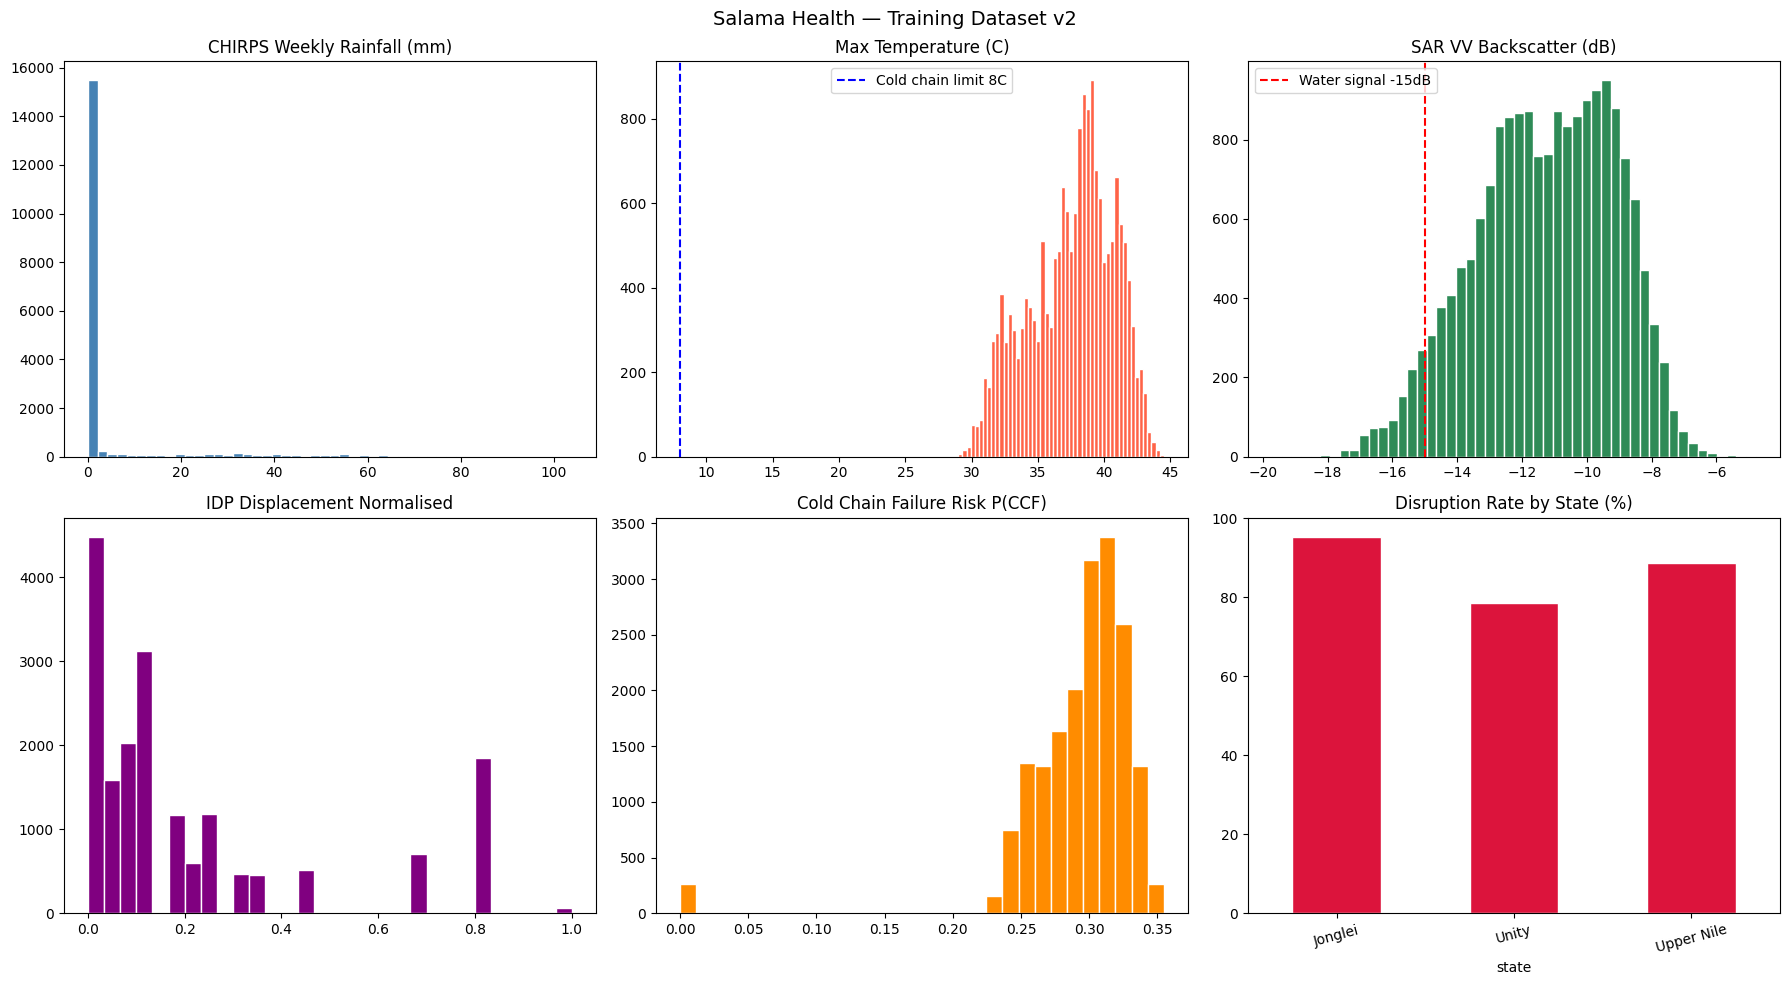

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df_final['chirps_rainfall_mm'].clip(0,200), bins=50,
               color='steelblue', edgecolor='white')
axes[0,0].set_title('CHIRPS Weekly Rainfall (mm)')

axes[0,1].hist(df_final['temp_max_celsius'].replace(0, np.nan).dropna(),
               bins=50, color='tomato', edgecolor='white')
axes[0,1].axvline(8, color='blue', linestyle='--', label='Cold chain limit 8C')
axes[0,1].set_title('Max Temperature (C)')
axes[0,1].legend()

axes[0,2].hist(df_final['VV_backscatter'].replace(0, np.nan).dropna(),
               bins=50, color='seagreen', edgecolor='white')
axes[0,2].axvline(-15, color='red', linestyle='--', label='Water signal -15dB')
axes[0,2].set_title('SAR VV Backscatter (dB)')
axes[0,2].legend()

axes[1,0].hist(df_final['idp_normalised'], bins=30,
               color='purple', edgecolor='white')
axes[1,0].set_title('IDP Displacement Normalised')

axes[1,1].hist(df_final['ccf_risk'], bins=30,
               color='darkorange', edgecolor='white')
axes[1,1].set_title('Cold Chain Failure Risk P(CCF)')

state_d = df_final.groupby('state')['disrupted'].mean() * 100
state_d.plot(kind='bar', ax=axes[1,2], color='crimson', edgecolor='white')
axes[1,2].set_title('Disruption Rate by State (%)')
axes[1,2].tick_params(axis='x', rotation=15)

plt.suptitle('Salama Health — Training Dataset v2', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/data_quality_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Filter to 2021-2024 to match CHIRPS coverage
df = df[df['date'].dt.year >= 2021].copy().reset_index(drop=True)

print(f'After date filter: {len(df):,} rows')
print(f'Date range:        {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Facilities:        {df["facility_name"].nunique()}')
print(f'Rainfall nulls:    {df["chirps_rainfall_mm"].isna().sum()}')
print(f'Temp nulls:        {df["temp_max_celsius"].isna().sum()}')

After date filter: 9,617 rows
Date range:        2021-01-02 to 2024-12-30
Facilities:        93
Rainfall nulls:    0
Temp nulls:        0


In [14]:
# SAR-based disruption label
# Time-aware — checks actual satellite signal for each specific week
df['disrupted'] = (
    (df['VV_backscatter'] < -17) &
    (df['rainy_season']   == 1)  &
    (df['low_elevation']  == 1)
).astype(int)

total     = len(df)
disrupted = df['disrupted'].sum()
print(f'Total:           {total:,}')
print(f'Disrupted:       {disrupted:,} ({disrupted/total*100:.2f}%)')
print(f'Not disrupted:   {total-disrupted:,}')
print(f'Class imbalance: {(total-disrupted)//max(disrupted,1)}:1')
print(df.groupby('state')['disrupted'].agg(['sum','mean'])
      .rename(columns={'sum':'count','mean':'rate'}))

Total:           9,617
Disrupted:       13 (0.14%)
Not disrupted:   9,604
Class imbalance: 738:1
            count      rate
state                      
Jonglei         0  0.000000
Unity          12  0.003256
Upper Nile      1  0.000495


In [15]:
# Check disruption rate at different VV thresholds
print('VV threshold | Disrupted | Rate')
print('-' * 40)
for threshold in [-14, -15, -16, -17, -18]:
    disrupted = (
        (df['VV_backscatter'] < threshold) &
        (df['rainy_season'] == 1) &
        (df['low_elevation'] == 1)
    ).sum()
    print(f'VV < {threshold:3d} dB   | {disrupted:6d}    | {disrupted/len(df)*100:.2f}%')

# Also check without elevation filter
print('\nWithout elevation filter:')
for threshold in [-14, -15, -16, -17]:
    disrupted = (
        (df['VV_backscatter'] < threshold) &
        (df['rainy_season'] == 1)
    ).sum()
    print(f'VV < {threshold:3d} dB   | {disrupted:6d}    | {disrupted/len(df)*100:.2f}%')

VV threshold | Disrupted | Rate
----------------------------------------
VV < -14 dB   |    253    | 2.63%
VV < -15 dB   |    122    | 1.27%
VV < -16 dB   |     31    | 0.32%
VV < -17 dB   |     13    | 0.14%
VV < -18 dB   |      0    | 0.00%

Without elevation filter:
VV < -14 dB   |    474    | 4.93%
VV < -15 dB   |    195    | 2.03%
VV < -16 dB   |     41    | 0.43%
VV < -17 dB   |     13    | 0.14%


In [16]:
df['disrupted'] = (
    (df['VV_backscatter'] < -14) &
    (df['rainy_season']   == 1)
).astype(int)

total     = len(df)
disrupted = df['disrupted'].sum()

print(f'Total:           {total:,}')
print(f'Disrupted:       {disrupted:,} ({disrupted/total*100:.2f}%)')
print(f'Not disrupted:   {total-disrupted:,}')
print(f'Class imbalance: {(total-disrupted)//max(disrupted,1)}:1')
print(df.groupby('state')['disrupted'].agg(['sum','mean'])
      .rename(columns={'sum':'count','mean':'rate'}))

Total:           9,617
Disrupted:       474 (4.93%)
Not disrupted:   9,143
Class imbalance: 19:1
            count      rate
state                      
Jonglei       200  0.051138
Unity         236  0.064043
Upper Nile     38  0.018803


In [17]:
df_final = df[META_COLS + FEATURE_COLS + ['disrupted']].copy()
output_path = f'{OUT_DIR}/SSD_Training_Dataset_v2.csv'
df_final.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'Shape:      {df_final.shape}')
print(f'Features:   {len(FEATURE_COLS)}')
print(f'Facilities: {df_final["facility_name"].nunique()}')
print(f'Disrupted:  {df_final["disrupted"].sum():,} ({df_final["disrupted"].mean()*100:.2f}%)')

Saved: /kaggle/working/SSD_Training_Dataset_v2.csv
Shape:      (9617, 41)
Features:   30
Facilities: 93
Disrupted:  474 (4.93%)
